# NYC 311 EDA

## Imports

In [1]:
import polars as pl
import pandas as pd

import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

sns.set_theme(style="whitegrid")

pl.enable_string_cache()

## Load dataset

In [2]:
CSV_PATH = Path("../data/raw/nyc_311_3M.csv")

df = pl.scan_csv(
    CSV_PATH,
    try_parse_dates=True,
    infer_schema_length=10000,
)

## Dataset overview

### Schema

In [3]:
schema = df.collect_schema()

schema

Schema([('unique_key', Int64),
        ('created_date', Datetime(time_unit='us', time_zone=None)),
        ('closed_date', Datetime(time_unit='us', time_zone=None)),
        ('agency', String),
        ('agency_name', String),
        ('complaint_type', String),
        ('descriptor', String),
        ('location_type', String),
        ('city', String),
        ('borough', String),
        ('latitude', Float64),
        ('longitude', Float64)])

### Number of rows

In [4]:
df.select(pl.len()).collect()

len
u32
3000000


### Preview

In [5]:
df.head(5).collect()

unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,city,borough,latitude,longitude
i64,datetime[μs],datetime[μs],str,str,str,str,str,str,str,f64,f64
69125656,2026-05-27 01:41:49,2026-05-27 01:55:57,"""NYPD""","""New York City Police Departmen…","""Noise - Commercial""","""Loud Talking""","""Club/Bar/Restaurant""","""BROOKLYN""","""BROOKLYN""",40.702777,-73.929386
69124281,2026-05-27 01:40:37,2026-05-27 01:50:25,"""NYPD""","""New York City Police Departmen…","""Noise - Street/Sidewalk""","""Loud Music/Party""","""Street/Sidewalk""",null,"""BROOKLYN""",40.621368,-74.031919
69124302,2026-05-27 01:40:07,2026-05-27 01:48:05,"""NYPD""","""New York City Police Departmen…","""Noise - Street/Sidewalk""","""Loud Talking""","""Street/Sidewalk""",null,"""BROOKLYN""",40.621368,-74.031919
69127457,2026-05-27 01:35:04,2026-05-27 01:35:04,"""DOT""","""Department of Transportation""","""Street Condition""","""Pothole""",null,"""BROOKLYN""","""BROOKLYN""",40.684513,-73.90938
69132454,2026-05-27 01:34:47,2026-05-27 02:02:36,"""NYPD""","""New York City Police Departmen…","""Noise - Residential""","""Banging/Pounding""","""Residential Building/House""","""BROOKLYN""","""BROOKLYN""",40.659998,-73.883059


## Null analysis

### Null counts

In [6]:
null_counts = df.select([pl.all().null_count()]).collect()

null_counts

unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,city,borough,latitude,longitude
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,344859,112650,0,0,0


### Null percentages

In [7]:
total_rows = df.select(pl.len()).collect().item()

null_percentages = (
    df.select(
        [
            ((pl.col(c).is_null().sum() / total_rows) * 100).alias(c)
            for c in df.collect_schema().names()
        ]
    )
    .collect()
)

null_percentages

unique_key,created_date,closed_date,agency,agency_name,complaint_type,descriptor,location_type,city,borough,latitude,longitude
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
0.0,0.0,0.0,0.0,0.0,0.0,0.0,11.4953,3.755,0.0,0.0,0.0


## Resolution time feature

### Create resolution minutes

In [8]:
df2 = df.with_columns(
    (pl.col("closed_date") - pl.col("created_date"))
    .dt.total_minutes()
    .alias("resolution_minutes")
)

### Basic statistics

In [9]:
resolution_stats = (
    df2.select(
        [
            pl.col("resolution_minutes").mean().alias("mean_resolution"),
            pl.col("resolution_minutes").median().alias("median_resolution"),
            pl.col("resolution_minutes").std().alias("std_resolution"),
            pl.col("resolution_minutes").min().alias("min_resolution"),
            pl.col("resolution_minutes").max().alias("max_resolution"),
        ]
    )
    .collect()
)

resolution_stats

mean_resolution,median_resolution,std_resolution,min_resolution,max_resolution
f64,f64,f64,i64,i64
8513.681996,386.0,27547.151629,0,436448


### Quantiles

In [10]:
quantiles = (
    df2.select(
        [
            pl.col("resolution_minutes").quantile(0.50).alias("p50"),
            pl.col("resolution_minutes").quantile(0.90).alias("p90"),
            pl.col("resolution_minutes").quantile(0.95).alias("p95"),
            pl.col("resolution_minutes").quantile(0.99).alias("p99"),
        ]
    )
    .collect()
)

quantiles

p50,p90,p95,p99
f64,f64,f64,f64
386.0,17961.0,45064.0,148215.0


In [11]:
zero_res = int(df2.filter(pl.col("resolution_minutes") == 0).select(pl.len()).collect().item())
same_dt = int(df2.filter(pl.col("created_date") == pl.col("closed_date")).select(pl.len()).collect().item())

print(f"{zero_res} rows with resolution_minutes == 0")
print(f"{same_dt} rows where created_date == closed_date")

56534 rows with resolution_minutes == 0
49991 rows where created_date == closed_date


### Plot distribution

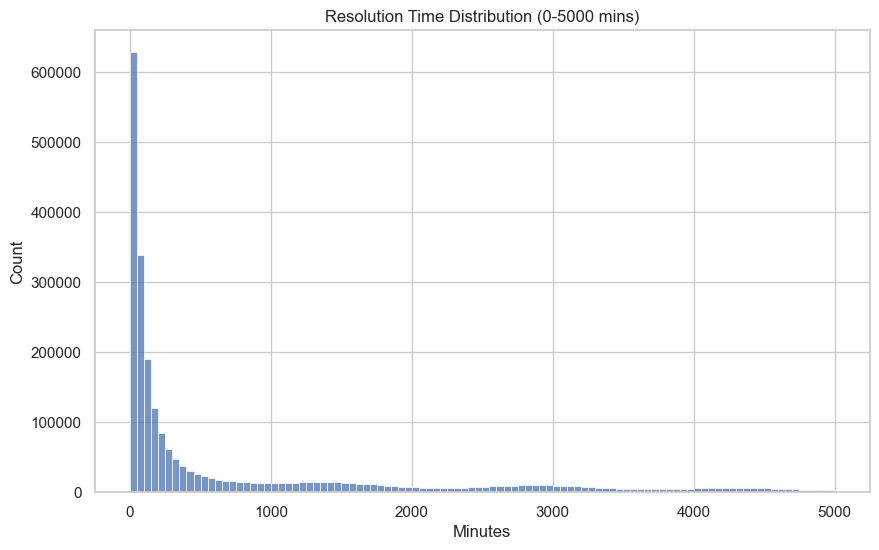

In [12]:
resolution_pd = (
    df2.select("resolution_minutes")
    .filter(pl.col("resolution_minutes").is_between(0, 5000))
    .collect()
    .to_pandas()
)

plt.figure(figsize=(10, 6))

sns.histplot(
    resolution_pd["resolution_minutes"],
    bins=100,
)

plt.title("Resolution Time Distribution (0-5000 mins)")
plt.xlabel("Minutes")
plt.ylabel("Count")

plt.show()

### Log Distribution
Useful for right-skewed service time distributions.

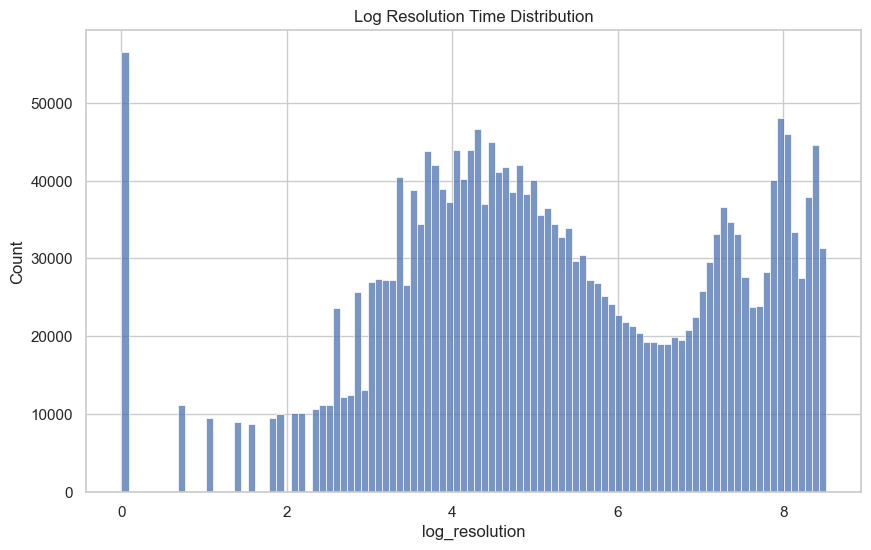

In [13]:
resolution_pd["log_resolution"] = np.log1p(resolution_pd["resolution_minutes"])

plt.figure(figsize=(10, 6))

sns.histplot(
    resolution_pd["log_resolution"],
    bins=100,
)

plt.title("Log Resolution Time Distribution")

plt.show()

## Complaint type distribution

### Counts

In [14]:
complaint_counts = (
    df.group_by("complaint_type")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .collect()
)

display(complaint_counts.head(20))
display(complaint_counts.tail(20))

complaint_type,count
str,u32
"""Illegal Parking""",493298
"""Noise - Residential""",369210
"""HEAT/HOT WATER""",336011
"""Blocked Driveway""",159084
"""Noise - Street/Sidewalk""",123259
…,…
"""Traffic Signal Condition""",43054
"""DOOR/WINDOW""",38286
"""Noise - Vehicle""",37068


complaint_type,count
str,u32
"""Building Marshal's Office""",10
"""Borough Office""",10
"""Wayfinding""",9
"""X-Ray Machine/Equipment""",8
"""Highway Condition""",8
…,…
"""Tanning""",2
"""Leaning Bar""",2
"""Trapping Pigeon""",1


### Plot top 20

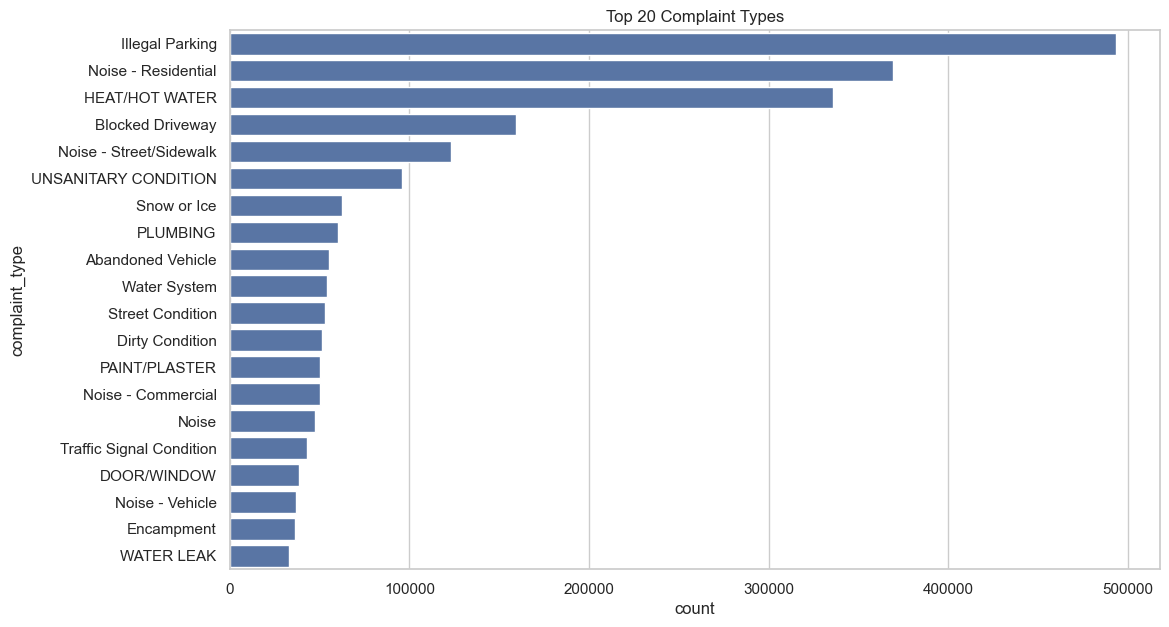

In [15]:
top20 = complaint_counts.head(20).to_pandas()

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top20,
    x="count",
    y="complaint_type",
)

plt.title("Top 20 Complaint Types")

plt.show()

In [16]:
df3 = df2.with_columns(
    [
        pl.col("created_date").dt.hour().alias("hour"),
        pl.col("created_date").dt.weekday().alias("weekday"),
    ]
)

df3 = df3.filter(
    (pl.col("resolution_minutes") > 0)
    & (pl.col("complaint_type") != "Unspecified")
)

## Quick temporal summary

## Complaints by hour

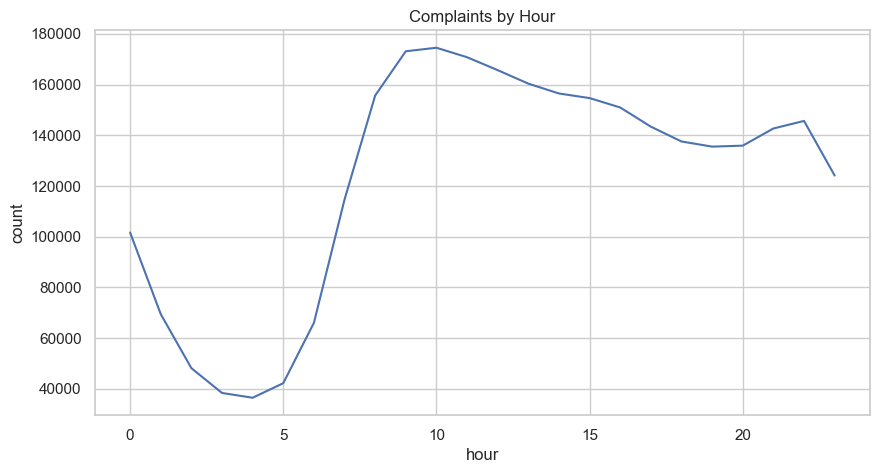

In [17]:
hour_counts = (
    df3.group_by("hour")
    .agg(pl.len().alias("count"))
    .sort("hour")
    .collect()
)

hour_pd = hour_counts.to_pandas()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hour_pd,
    x="hour",
    y="count",
)

plt.title("Complaints by Hour")

plt.show()

## Resolution time by hour

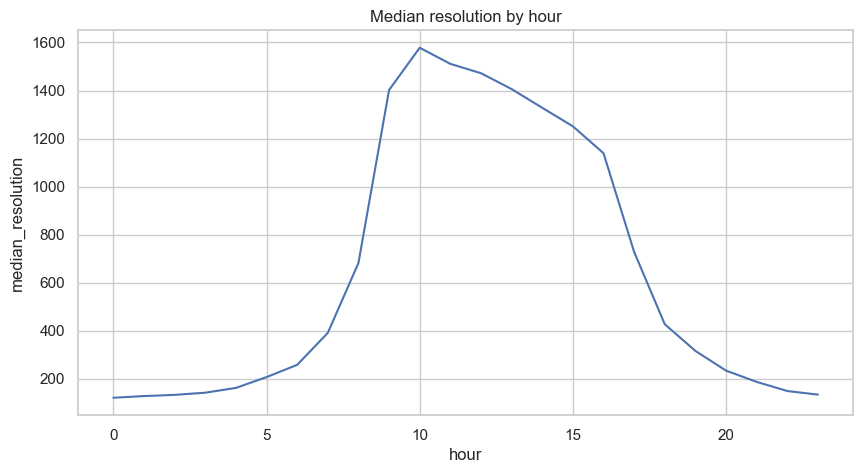

In [18]:
hour_resolution = (
    df3.group_by("hour")
    .agg(
        pl.col("resolution_minutes")
        .median()
        .alias("median_resolution")
    )
    .sort("hour")
    .collect()
)

hour_resolution_pd = hour_resolution.to_pandas()

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=hour_resolution_pd,
    x="hour",
    y="median_resolution",
)

plt.title("Median resolution by hour")

plt.show()

## Complaints by weekday

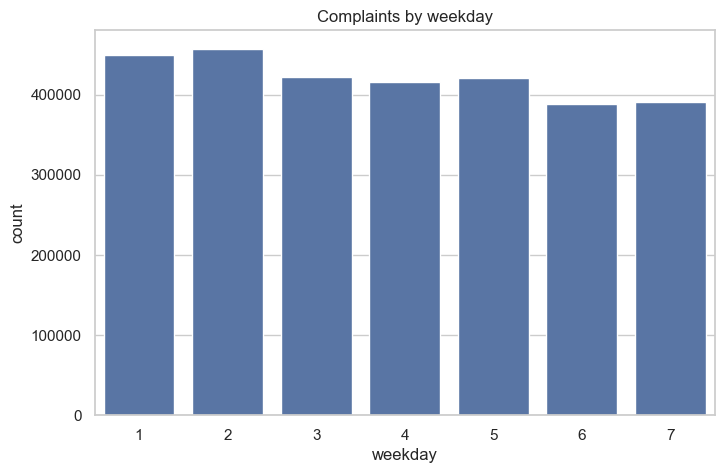

In [19]:
weekday_counts = (
    df3.group_by("weekday")
    .agg(pl.len().alias("count"))
    .sort("weekday")
    .collect()
)

weekday_pd = weekday_counts.to_pandas()

plt.figure(figsize=(8, 5))

sns.barplot(
    data=weekday_pd,
    x="weekday",
    y="count",
)

plt.title("Complaints by weekday")

plt.show()

## Resolution by complaint type

### Median resolution per complaint

In [20]:
resolution_by_complaint = (
    df3.group_by("complaint_type")
    .agg(
        pl.col("resolution_minutes")
        .median()
        .alias("median_resolution")
    )
    .sort("median_resolution", descending=True)
    .collect()
)

### Plot top 20 slowest

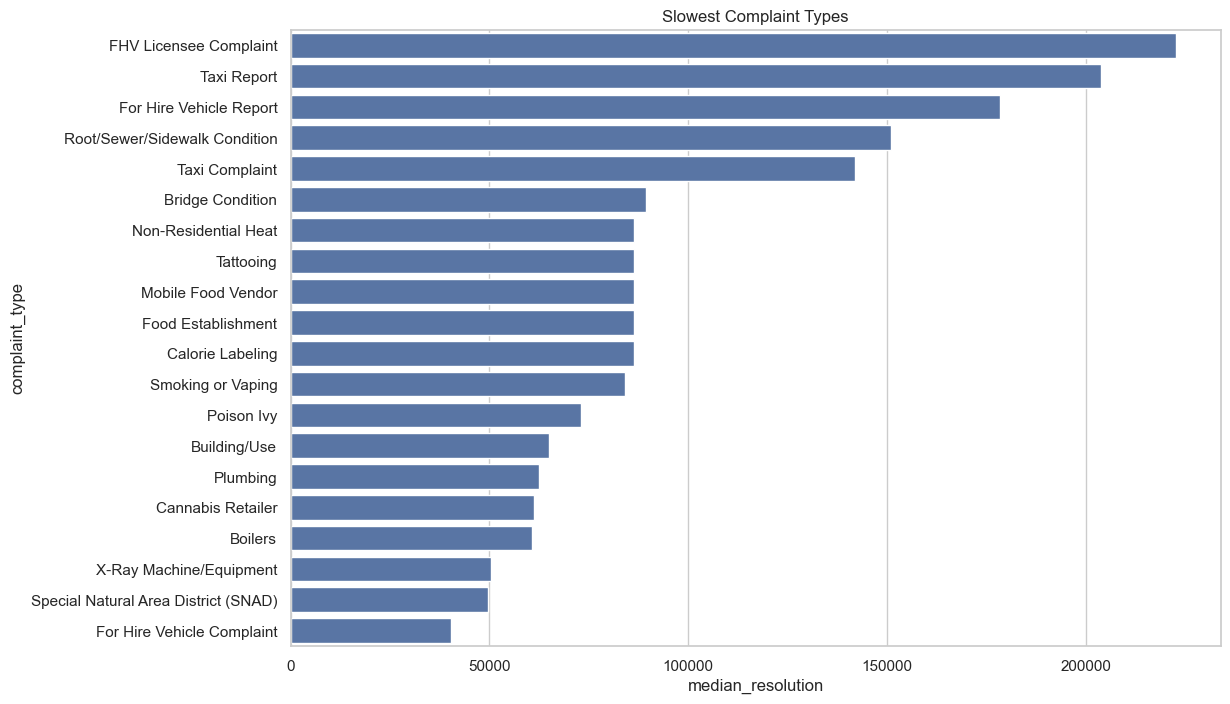

In [21]:
slowest = resolution_by_complaint.head(20).to_pandas()

plt.figure(figsize=(12, 8))

sns.barplot(
    data=slowest,
    x="median_resolution",
    y="complaint_type",
)

plt.title("Slowest Complaint Types")

plt.show()

## Descriptor distribution

In [22]:
analysis_cols = ["complaint_type", "descriptor", "location_type"]
placeholder_specs = [
    (None, "NULL", "actual missing value"),
    ("", "EMPTY STRING", "blank placeholder"),
    ("N/A", "UNKNOWN", "placeholder text"),
    ("NA", "UNKNOWN", "placeholder text"),
    ("n/a", "UNKNOWN", "placeholder text"),
    ("Unspecified", "UNKNOWN", "explicit unspecified label"),
    ("Unknown", "UNKNOWN", "explicit unknown label"),
    ("UNKNOWN", "UNKNOWN", "explicit unknown label"),
    ("Other/Unknown", "UNKNOWN", "mixed placeholder"),
    ("Other", "OTHER", "explicit other category"),
    ("Other (Explain Below)", "OTHER", "explicit other category"),
    ("Other (complaint details)", "OTHER", "explicit other category"),
    ("Other - Explain Below", "OTHER", "explicit other category"),
    ("Other (explain in Complaint Details)", "OTHER", "explicit other category"),
]

feature_rows = []
placeholder_rows = []
placeholder_frequency_rows = []
feature_counts = {}

for col in analysis_cols:
    counts = (
        df3.group_by(col)
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect()
    )
    feature_counts[col] = counts
    total = int(counts["count"].sum())
    nulls = int(counts.filter(pl.col(col).is_null())["count"].sum())
    empties = int(counts.filter(pl.col(col) == "")["count"].sum())
    uniques = counts.height
    na_like = 0
    for token, _, _ in placeholder_specs:
        if token is None:
            na_like += int(counts.filter(pl.col(col).is_null())["count"].sum())
        else:
            na_like += int(counts.filter(pl.col(col) == token)["count"].sum())
    feature_rows.append(
        {
            "feature": col,
            "total_rows": total,
            "unique_values": uniques,
            "nulls": nulls,
            "empty_strings": empties,
            "na_like_values": na_like,
        }
    )

    for token, group_name, note in placeholder_specs:
        if token is None:
            placeholder_count = int(counts.filter(pl.col(col).is_null())["count"].sum())
            label = "<NULL>"
        else:
            placeholder_count = int(counts.filter(pl.col(col) == token)["count"].sum())
            label = token
        if placeholder_count > 0:
            placeholder_rows.append(
                {
                    "feature": col,
                    "placeholder": label,
                    "group": group_name,
                    "note": note,
                    "count": placeholder_count,
                    "pct_of_dataset": round(placeholder_count / total * 100, 4),
                }
            )
            placeholder_frequency_rows.append(
                {
                    "feature": col,
                    "placeholder": label,
                    "group": group_name,
                    "count": placeholder_count,
                    "pct_of_dataset": round(placeholder_count / total * 100, 4),
                    "rarity_bucket": "<10"
                    if placeholder_count < 10
                    else "<100"
                    if placeholder_count < 100
                    else "<1000"
                    if placeholder_count < 1000
                    else ">=1000",
                }
            )

overview_table = pl.DataFrame(feature_rows)
placeholder_inventory_table = pl.DataFrame(placeholder_rows).sort(
    ["feature", "count"], descending=[False, True]
)
placeholder_frequency_table = pl.DataFrame(placeholder_frequency_rows).sort(
    "count", descending=True
)

print("Section 1 summary")
display(overview_table.head(11))

print("Section 2 placeholder inventory")
display(placeholder_inventory_table.head(11))

print("Section 3 frequency ranking")
display(placeholder_frequency_table.head(11))

Section 1 summary


feature,total_rows,unique_values,nulls,empty_strings,na_like_values
str,i64,i64,i64,i64,i64
"""complaint_type""",2943446,173,0,0,0
"""descriptor""",2943446,862,0,0,71572
"""location_type""",2943446,138,309488,0,315666


Section 2 placeholder inventory


feature,placeholder,group,note,count,pct_of_dataset
str,str,str,str,i64,f64
"""descriptor""","""N/A""","""UNKNOWN""","""placeholder text""",51377,1.7455
"""descriptor""","""Other (complaint details)""","""OTHER""","""explicit other category""",15320,0.5205
"""descriptor""","""Other/Unknown""","""UNKNOWN""","""mixed placeholder""",2487,0.0845
"""descriptor""","""Other""","""OTHER""","""explicit other category""",1251,0.0425
"""descriptor""","""Other (Explain Below)""","""OTHER""","""explicit other category""",1110,0.0377
…,…,…,…,…,…
"""location_type""","""<NULL>""","""NULL""","""actual missing value""",309488,10.5145
"""location_type""","""Other""","""OTHER""","""explicit other category""",4236,0.1439
"""location_type""","""Other (Explain Below)""","""OTHER""","""explicit other category""",1840,0.0625


Section 3 frequency ranking


feature,placeholder,group,count,pct_of_dataset,rarity_bucket
str,str,str,i64,f64,str
"""location_type""","""<NULL>""","""NULL""",309488,10.5145,""">=1000"""
"""descriptor""","""N/A""","""UNKNOWN""",51377,1.7455,""">=1000"""
"""descriptor""","""Other (complaint details)""","""OTHER""",15320,0.5205,""">=1000"""
"""location_type""","""Other""","""OTHER""",4236,0.1439,""">=1000"""
"""descriptor""","""Other/Unknown""","""UNKNOWN""",2487,0.0845,""">=1000"""
…,…,…,…,…,…
"""descriptor""","""Other""","""OTHER""",1251,0.0425,""">=1000"""
"""descriptor""","""Other (Explain Below)""","""OTHER""",1110,0.0377,""">=1000"""
"""location_type""","""N/A""","""UNKNOWN""",68,0.0023,"""<100"""


In [23]:
analysis_cols = ["complaint_type", "descriptor", "location_type"]

def _raw(col):
    return pl.col(col).cast(pl.Utf8)

def _stripped(col):
    return _raw(col).str.strip_chars()

def _lower(col):
    return _stripped(col).str.to_lowercase()

for col in analysis_cols:
    print(f"Potential placeholder candidates in {col} (lowercased + stripped)")
    candidates = (
        df3.select(_lower(col).alias("value"))
        .filter(pl.col("value").is_not_null())
        .filter(
            pl.col("value").str.contains("other", literal=True)
            | pl.col("value").str.contains("unknown", literal=True)
            | pl.col("value").str.contains("n/a", literal=True)
        )
        .group_by("value")
        .agg(pl.len().alias("count"))
        .sort("count", descending=True)
        .collect()
    )
    display(candidates.head(20))

for col in analysis_cols:
    print(f"Case variants for {col} (normalized buckets with >1 raw value)")
    case_variants = (
        df3.select(
            [
                _raw(col).alias("raw"),
                _lower(col).alias("normalized"),
            ]
        )
        .filter(pl.col("raw").is_not_null())
        .group_by("normalized")
        .agg(
            [
                pl.col("raw").n_unique().alias("raw_variants"),
                pl.col("raw").unique().alias("raw_examples"),
                pl.len().alias("count"),
            ]
        )
        .filter(
            (pl.col("raw_variants") > 1)
            & (pl.col("count") >= 100)
        )
        .sort("raw_variants", descending=True)
        .collect()
    )
    display(case_variants.head(20))

    print(f"Leading/trailing whitespace variants for {col}")
    whitespace_variants = (
        df3.select(
            [
                _raw(col).alias("raw"),
                _stripped(col).alias("stripped"),
            ]
        )
        .filter(pl.col("raw").is_not_null() & (pl.col("raw") != pl.col("stripped")))
        .group_by("raw")
        .agg(
            [
                pl.first("stripped").alias("stripped"),
                pl.len().alias("count"),
            ]
        )
        .sort("count", descending=True)
        .collect()
    )
    display(whitespace_variants.head(20))

placeholder_specs = [
    {"token": None, "label": "<NULL>", "group": "UNKNOWN"},
    {"token": "", "label": "EMPTY STRING", "group": "UNKNOWN"},
    {"token": "n/a", "label": "N/A", "group": "UNKNOWN"},
    {"token": "na", "label": "NA", "group": "UNKNOWN"},
    {"token": "unknown", "label": "Unknown", "group": "UNKNOWN"},
    {"token": "unspecified", "label": "Unspecified", "group": "UNKNOWN"},
    {"token": "other/unknown", "label": "Other/Unknown", "group": "UNKNOWN"},
    {"token": "other", "label": "Other", "group": "OTHER"},
    {
        "token": "other (complaint details)",
        "label": "Other (complaint details)",
        "group": "OTHER",
    },
    {
        "token": "other (explain below)",
        "label": "Other (Explain Below)",
        "group": "OTHER",
    },
    {
        "token": "other - explain below",
        "label": "Other - Explain Below",
        "group": "OTHER",
    },
    {
        "token": "other (explain in complaint details)",
        "label": "Other (explain in Complaint Details)",
        "group": "OTHER",
    },
]

unknown_tokens = [
    spec["token"]
    for spec in placeholder_specs
    if spec["group"] == "UNKNOWN" and spec["token"] is not None
]
other_tokens = [
    spec["token"]
    for spec in placeholder_specs
    if spec["group"] == "OTHER" and spec["token"] is not None
]


def _token_key(token):
    if token is None:
        return "null"
    if token == "":
        return "empty"
    return "".join(ch if ch.isalnum() else "_" for ch in token)


total_rows = int(df3.select(pl.len()).collect().item())

count_exprs = []
for col in analysis_cols:
    count_exprs.append(pl.col(col).is_null().sum().alias(f"{col}__null"))
    normalized = _lower(col)
    for token in [spec["token"] for spec in placeholder_specs if spec["token"] is not None]:
        key = _token_key(token)
        count_exprs.append((normalized == token).sum().alias(f"{col}__{key}"))

counts_row = df3.select(count_exprs).collect().row(0, named=True)

rows = []
for col in analysis_cols:
    for spec in placeholder_specs:
        if spec["token"] is None:
            key = f"{col}__null"
        else:
            key = f"{col}__{_token_key(spec['token'])}"
        count = int(counts_row.get(key, 0))
        if count > 0:
            rows.append(
                {
                    "feature": col,
                    "placeholder": spec["label"],
                    "group": spec["group"],
                    "count": count,
                    "pct": round(count / total_rows * 100, 4),
                }
            )

freq_table = pl.DataFrame(rows).sort(["feature", "count"], descending=[False, True])
print("Placeholder frequencies (pre-normalization, case- and whitespace-aware)")
display(freq_table)

pre_norm_rows = []
for col in analysis_cols:
    unknown_count = 0
    other_count = 0
    for spec in placeholder_specs:
        if spec["token"] is None:
            key = f"{col}__null"
        else:
            key = f"{col}__{_token_key(spec['token'])}"
        count = int(counts_row.get(key, 0))
        if spec["group"] == "UNKNOWN":
            unknown_count += count
        else:
            other_count += count
    pre_norm_rows.append(
        {
            "feature": col,
            "UNKNOWN_rows": unknown_count,
            "UNKNOWN_pct": round(unknown_count / total_rows * 100, 2),
            "OTHER_rows": other_count,
            "OTHER_pct": round(other_count / total_rows * 100, 2),
        }
    )

pre_norm_df = pl.DataFrame(pre_norm_rows)
print("Combined UNKNOWN/OTHER counts (pre-normalization)")
display(pre_norm_df)

exprs = []
for col in analysis_cols:
    raw = _raw(col)
    stripped = _stripped(col)
    lowered = stripped.str.to_lowercase()
    exprs.append(
        pl.when(raw.is_null())
        .then(pl.lit("UNKNOWN"))
        .when(lowered.is_in(unknown_tokens))
        .then(pl.lit("UNKNOWN"))
        .when(lowered.is_in(other_tokens))
        .then(pl.lit("OTHER"))
        .otherwise(stripped)
        .alias(col)
    )

df3_normalized = df3.with_columns(exprs)

before_exprs = []
after_exprs = []
affected_exprs = []
for col in analysis_cols:
    before_exprs.append(pl.col(col).n_unique().alias(f"{col}__unique_before"))
    after_exprs.append(pl.col(col).n_unique().alias(f"{col}__unique_after"))
    after_exprs.append((pl.col(col) == "UNKNOWN").sum().alias(f"{col}__unknown"))
    after_exprs.append((pl.col(col) == "OTHER").sum().alias(f"{col}__other"))

    raw = _raw(col)
    stripped = _stripped(col)
    lowered = stripped.str.to_lowercase()
    normalized_value = (
        pl.when(raw.is_null())
        .then(pl.lit("UNKNOWN"))
        .when(lowered.is_in(unknown_tokens))
        .then(pl.lit("UNKNOWN"))
        .when(lowered.is_in(other_tokens))
        .then(pl.lit("OTHER"))
        .otherwise(stripped)
    )
    affected_exprs.append(
        pl.when(raw.is_null())
        .then(1)
        .when(normalized_value != raw)
        .then(1)
        .otherwise(0)
        .sum()
        .alias(f"{col}__affected")
    )

before_counts = df3.select(before_exprs).collect().row(0, named=True)
after_counts = df3_normalized.select(after_exprs).collect().row(0, named=True)
affected_counts = df3.select(affected_exprs).collect().row(0, named=True)

impact_rows = []
for col in analysis_cols:
    before = int(before_counts[f"{col}__unique_before"])
    after = int(after_counts[f"{col}__unique_after"])
    unknown_count = int(after_counts[f"{col}__unknown"])
    other_count = int(after_counts[f"{col}__other"])
    affected = int(affected_counts[f"{col}__affected"])
    impact_rows.append(
        {
            "feature": col,
            "unique_before": before,
            "unique_after": after,
            "reduction": before - after,
            "affected_rows": affected,
            "affected_pct": round(affected / total_rows * 100, 2),
            "UNKNOWN_pct": round(unknown_count / total_rows * 100, 2),
            "OTHER_pct": round(other_count / total_rows * 100, 2),
        }
    )

impact_df = pl.DataFrame(impact_rows)
print("Cardinality impact (post-normalization)")
display(impact_df)

Potential placeholder candidates in complaint_type (lowercased + stripped)


value,count
str,u32


Potential placeholder candidates in descriptor (lowercased + stripped)


value,count
str,u32
"""n/a""",51377
"""other (complaint details)""",15320
"""other/unknown""",2487
"""waste left in front of other r…",1315
"""other""",1251
…,…
"""damaged other""",111
"""other animal""",109
"""wasting faucets,sinks,flushome…",96


Potential placeholder candidates in location_type (lowercased + stripped)


...

feature,placeholder,group,count,pct
str,str,str,i64,f64
"""descriptor""","""N/A""","""UNKNOWN""",51377,1.7455
"""descriptor""","""Other (complaint details)""","""OTHER""",15320,0.5205
"""descriptor""","""Other/Unknown""","""UNKNOWN""",2487,0.0845
"""descriptor""","""Other""","""OTHER""",1251,0.0425
"""descriptor""","""Other (Explain Below)""","""OTHER""",1110,0.0377
…,…,…,…,…
"""location_type""","""<NULL>""","""UNKNOWN""",309488,10.5145
"""location_type""","""Other""","""OTHER""",4236,0.1439
"""location_type""","""Other (Explain Below)""","""OTHER""",1840,0.0625


Combined UNKNOWN/OTHER counts (pre-normalization)


feature,UNKNOWN_rows,UNKNOWN_pct,OTHER_rows,OTHER_pct
str,i64,f64,i64,f64
"""complaint_type""",0,0.0,0,0.0
"""descriptor""",53864,1.83,17708,0.6
"""location_type""",309556,10.52,6110,0.21


Cardinality impact (post-normalization)


feature,unique_before,unique_after,reduction,affected_rows,affected_pct,UNKNOWN_pct,OTHER_pct
str,i64,i64,i64,i64,f64,f64,f64
"""complaint_type""",173,173,0,0,0.0,0.0,0.0
"""descriptor""",862,858,4,71572,2.43,1.83,0.6
"""location_type""",138,135,3,315666,10.72,10.52,0.21


In [24]:
title_exprs = []

for col in analysis_cols:
    title_exprs.append(
        pl.when(pl.col(col).is_in(["UNKNOWN", "OTHER"]))
        .then(pl.col(col))
        .otherwise(
            pl.col(col)
            .cast(pl.Utf8)
            .str.strip_chars()
            .str.to_lowercase()
            .str.to_titlecase()
        )
        .alias(col)
    )

df3_clean = df3_normalized.with_columns(title_exprs)

capitalization_impact = []

for col in analysis_cols:
    before = int(
        df3_normalized.select(pl.col(col).n_unique())
        .collect()
        .item()
    )

    after = int(
        df3_clean.select(pl.col(col).n_unique())
        .collect()
        .item()
    )

    capitalization_impact.append(
        {
            "feature": col,
            "unique_before": before,
            "unique_after": after,
            "reduction": before - after,
        }
    )

capitalization_impact_df = pl.DataFrame(capitalization_impact)

print("Capitalization normalization impact")
display(capitalization_impact_df)

Capitalization normalization impact


feature,unique_before,unique_after,reduction
str,i64,i64,i64
"""complaint_type""",173,171,2
"""descriptor""",858,855,3
"""location_type""",135,134,1


### Pair counts

In [25]:
pair_counts = (
    df3_clean.group_by(["complaint_type", "descriptor"])
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .collect()
)

pair_counts.head(20)

complaint_type,descriptor,count
str,str,u32
"""Heat/Hot Water""","""Entire Building""",217707
"""Noise - Residential""","""Loud Music/Party""",217133
"""Illegal Parking""","""Blocked Hydrant""",138519
"""Blocked Driveway""","""No Access""",120361
"""Heat/Hot Water""","""Apartment Only""",118237
…,…,…
"""Illegal Parking""","""Commercial Overnight Parking""",35158
"""Snow Or Ice""","""Sidewalk""",33737
"""Illegal Parking""","""Blocked Crosswalk""",30543


### Rare pairs

In [26]:
rare_pairs = pair_counts.filter(pl.col("count") <= 50)

rare_pairs.head(20)

complaint_type,descriptor,count
str,str,u32
"""Street Condition""","""Plate Condition - Open""",50
"""Industrial Waste""","""Chemical Spill (Iac)""",50
"""Building Drinking Water Tank""","""Unsanitary Condition""",49
"""Traffic Signal Condition""","""On Messenger""",48
"""Consumer Complaint""","""Home Appliance Store""",48
…,…,…
"""Water Quality""","""Cloudy Or Milky, Other (Use Co…",44
"""Sidewalk Condition""","""Sidewalk Staircase""",43
"""Water Conservation""","""Illegal Use Of Hose - Private …",43


## Filtering threshold simulation

In [27]:
cols = ["complaint_type", "descriptor", "location_type"]

for col in cols:
    print(f"\n--- {col} ---")

    counts = (
        df3_clean
        .group_by(col)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
        .collect()
    )

    print(counts.head(20))

    total = int(df3_clean.select(pl.len()).collect().item())
    nulls = int(df3_clean.filter(pl.col(col).is_null()).select(pl.len()).collect().item())
    empties = int(df3_clean.filter(pl.col(col) == "").select(pl.len()).collect().item())
    uniques = int(df3_clean.select(pl.col(col).n_unique()).collect().item())
    na_like = int(
        df3_clean.filter(pl.col(col).is_in(["N/A", "NA", "n/a", "Unknown", "UNKNOWN", "-", "None", "null", "Other", ""]))
        .select(pl.len())
        .collect()
        .item()
    )

    print(f"Total rows: {total}")
    print(f"Unique values: {uniques}")
    print(f"Nulls: {nulls} ({nulls/total*100:.4f}%)")
    print(f"Empty strings: {empties} ({empties/total*100:.4f}%)")
    print(f"NA-like values: {na_like} ({na_like/total*100:.4f}%)")


--- complaint_type ---
shape: (20, 2)
┌──────────────────────────┬────────┐
│ complaint_type           ┆ n      │
│ ---                      ┆ ---    │
│ str                      ┆ u32    │
╞══════════════════════════╪════════╡
│ Illegal Parking          ┆ 492264 │
│ Noise - Residential      ┆ 366294 │
│ Heat/Hot Water           ┆ 335944 │
│ Blocked Driveway         ┆ 159049 │
│ Noise - Street/Sidewalk  ┆ 122950 │
│ …                        ┆ …      │
│ Door/Window              ┆ 38283  │
│ Traffic Signal Condition ┆ 37861  │
│ Noise - Vehicle          ┆ 36733  │
│ Encampment               ┆ 36319  │
│ Water Leak               ┆ 33172  │
└──────────────────────────┴────────┘
Total rows: 2943446
Unique values: 171
Nulls: 0 (0.0000%)
Empty strings: 0 (0.0000%)
NA-like values: 0 (0.0000%)

--- descriptor ---
shape: (20, 2)
┌────────────────────────────────┬────────┐
│ descriptor                     ┆ n      │
│ ---                            ┆ ---    │
│ str                            ┆ 

In [28]:
df3_clean.filter(
    (pl.col("complaint_type") == "Unspecified")
    | (pl.col("descriptor") == "Unspecified")
    | (pl.col("location_type") == "Unspecified")
).select(pl.len()).collect()

len
u32
0


In [29]:
TOTAL_ROWS = (
    df3_clean
    .select(pl.len())
    .collect()
    .item()
)

COMBINATIONS = [
    ["complaint_type", "descriptor"],
    ["complaint_type", "location_type"],
    ["descriptor", "location_type"],
    ["complaint_type", "descriptor", "location_type"],
]

THRESHOLDS = [50, 100, 200, 500, 1000]

for cols in COMBINATIONS:
    print("\n" + "=" * 80)
    print(" + ".join(cols))
    print("=" * 80)

    combo_counts = (
        df3_clean.lazy()
        .group_by(cols)
        .agg(pl.len().alias("n"))
        .collect()
    )

    stats = combo_counts.select(
        [
            pl.len().alias("unique_combos"),
            pl.col("n").mean().alias("avg_support"),
            pl.col("n").median().alias("median_support"),
            pl.col("n").min().alias("min_support"),
            pl.col("n").quantile(0.10).alias("p10"),
            pl.col("n").quantile(0.25).alias("p25"),
            pl.col("n").quantile(0.75).alias("p75"),
            pl.col("n").max().alias("max_support"),
        ]
    )

    print(stats)

    threshold_results = []

    for t in THRESHOLDS:
        rare = combo_counts.filter(pl.col("n") < t)

        rare_combos = rare.height
        rare_rows = int(rare["n"].sum()) if rare.height > 0 else 0

        remaining_rows = TOTAL_ROWS - rare_rows

        threshold_results.append(
            {
                "threshold": t,
                "rare_combos": rare_combos,
                "rare_rows": rare_rows,
                "rare_rows_pct": round(rare_rows / TOTAL_ROWS * 100, 4),
                "remaining_rows": remaining_rows,
                "remaining_pct": round(
                    remaining_rows / TOTAL_ROWS * 100, 4
                ),
            }
        )

    threshold_df = pl.DataFrame(threshold_results)

    print("\nThreshold analysis:")
    print(threshold_df)


complaint_type + descriptor
shape: (1, 8)
┌───────────────┬─────────────┬────────────────┬─────────────┬─────┬──────┬───────┬─────────────┐
│ unique_combos ┆ avg_support ┆ median_support ┆ min_support ┆ p10 ┆ p25  ┆ p75   ┆ max_support │
│ ---           ┆ ---         ┆ ---            ┆ ---         ┆ --- ┆ ---  ┆ ---   ┆ ---         │
│ u32           ┆ f64         ┆ f64            ┆ u32         ┆ f64 ┆ f64  ┆ f64   ┆ u32         │
╞═══════════════╪═════════════╪════════════════╪═════════════╪═════╪══════╪═══════╪═════════════╡
│ 980           ┆ 3003.516327 ┆ 148.0          ┆ 1           ┆ 3.0 ┆ 17.0 ┆ 827.0 ┆ 217707      │
└───────────────┴─────────────┴────────────────┴─────────────┴─────┴──────┴───────┴─────────────┘

Threshold analysis:
shape: (5, 6)
┌───────────┬─────────────┬───────────┬───────────────┬────────────────┬───────────────┐
│ threshold ┆ rare_combos ┆ rare_rows ┆ rare_rows_pct ┆ remaining_rows ┆ remaining_pct │
│ ---       ┆ ---         ┆ ---       ┆ ---           ┆ --

In [30]:
combo_counts.with_columns(
    (pl.col("n") / TOTAL_ROWS * 100).alias("row_share")
).sort("n", descending=True)

complaint_type,descriptor,location_type,n,row_share
str,str,str,u32,f64
"""Heat/Hot Water""","""Entire Building""","""Residential Building""",217707,7.396331
"""Noise - Residential""","""Loud Music/Party""","""Residential Building/House""",217133,7.37683
"""Illegal Parking""","""Blocked Hydrant""","""Street/Sidewalk""",138519,4.706015
"""Blocked Driveway""","""No Access""","""Street/Sidewalk""",120361,4.089119
"""Heat/Hot Water""","""Apartment Only""","""Residential Building""",118237,4.016958
…,…,…,…,…
"""Street Light Condition""","""Fire Alarm Lamp Missing""","""UNKNOWN""",1,0.000034
"""Taxi Complaint""","""Driver Complaint - Non Passeng…","""Bridge""",1,0.000034
"""School Maintenance""","""Broken Window""","""School""",1,0.000034


In [31]:
combo_counts.sort("n", descending=True).with_columns(
    pl.col("n").cum_sum().alias("cum_rows")
).with_columns(
    (pl.col("cum_rows") / TOTAL_ROWS * 100).alias("cum_pct")
)

complaint_type,descriptor,location_type,n,cum_rows,cum_pct
str,str,str,u32,u32,f64
"""Heat/Hot Water""","""Entire Building""","""Residential Building""",217707,217707,7.396331
"""Noise - Residential""","""Loud Music/Party""","""Residential Building/House""",217133,434840,14.77316
"""Illegal Parking""","""Blocked Hydrant""","""Street/Sidewalk""",138519,573359,19.479175
"""Blocked Driveway""","""No Access""","""Street/Sidewalk""",120361,693720,23.568294
"""Heat/Hot Water""","""Apartment Only""","""Residential Building""",118237,811957,27.585252
…,…,…,…,…,…
"""Street Light Condition""","""Fire Alarm Lamp Missing""","""UNKNOWN""",1,2943442,99.999864
"""Taxi Complaint""","""Driver Complaint - Non Passeng…","""Bridge""",1,2943443,99.999898
"""School Maintenance""","""Broken Window""","""School""",1,2943444,99.999932


In [32]:
MIN_SUPPORT = 200

df3_filtered = (
    df3_clean
    .with_columns(
        pl.len()
        .over(["complaint_type", "descriptor", "location_type"])
        .alias("combo_count")
    )
    .filter(pl.col("combo_count") >= MIN_SUPPORT)
    .drop("combo_count")
)

summary = (
    df3_filtered
    .select(pl.len().alias("remaining_rows"))
    .collect()
)

remaining_rows = summary["remaining_rows"][0]

print(f"Remaining rows: {remaining_rows:,}")
print(f"Removed rows: {TOTAL_ROWS - remaining_rows:,}")
print(f"Remaining %: {remaining_rows / TOTAL_ROWS * 100:.2f}%")

Remaining rows: 2,904,438
Removed rows: 39,008
Remaining %: 98.67%


In [33]:
df_counts = df3_filtered.select(
    ["complaint_type", "descriptor", "location_type"]
).collect()

least_common_complaints = (
    df_counts
    .group_by("complaint_type")
    .agg(pl.len().alias("count"))
    .sort("count")
)

least_common_descriptors = (
    df_counts
    .group_by("descriptor")
    .agg(pl.len().alias("count"))
    .sort("count")
)

least_common_locations = (
    df_counts
    .group_by("location_type")
    .agg(pl.len().alias("count"))
    .sort("count")
)

least_common_combo = (
    df_counts
    .group_by(["complaint_type", "descriptor", "location_type"])
    .agg(pl.len().alias("count"))
    .sort("count")
)

print("Least common complaint types:")
display(least_common_complaints)
print("\nLeast common descriptors:")
display(least_common_descriptors)
print("\nLeast common location types:")
display(least_common_locations)
print("\nLeast common complaint+descriptor+location combos:")
display(least_common_combo)

Least common complaint types:


complaint_type,count
str,u32
"""Bike Rack""",219
"""Unleashed Dog""",233
"""Bus Stop Shelter Placement""",234
"""Indoor Sewage""",246
"""Mold""",248
…,…
"""Noise - Street/Sidewalk""",122950
"""Blocked Driveway""",159049
"""Heat/Hot Water""",335944



Least common descriptors:


descriptor,count
str,u32
"""Pavement""",203
"""Lamppost Base Door/Cover Open""",203
"""Bbq Outside Authorized Area""",204
"""Advertising Sign/Billboard/Pos…",206
"""Food Worker Hygiene""",211
…,…
"""No Access""",120361
"""Banging/Pounding""",123866
"""Blocked Hydrant""",138519



Least common location types:


location_type,count
str,u32
"""Public/Unfenced Area""",233
"""Apartment""",235
"""Private School""",283
"""House And Store""",326
"""Common Area""",392
…,…
"""Street""",227973
"""UNKNOWN""",300181
"""Residential Building/House""",397260



Least common complaint+descriptor+location combos:


complaint_type,descriptor,location_type,count
str,str,str,u32
"""Animal-Abuse""","""Neglected""","""Store/Commercial""",202
"""Street Light Condition""","""Lamppost Base Door/Cover Open""","""UNKNOWN""",203
"""Outside Building""","""Pavement""","""Residential Building""",203
"""Maintenance Or Facility""","""Structure - Outdoors""","""Street/Curbside""",203
"""Violation Of Park Rules""","""Bbq Outside Authorized Area""","""Park""",204
…,…,…,…
"""Heat/Hot Water""","""Apartment Only""","""Residential Building""",118237
"""Blocked Driveway""","""No Access""","""Street/Sidewalk""",120361
"""Illegal Parking""","""Blocked Hydrant""","""Street/Sidewalk""",138519


## Export tables

### Agency mapping

In [34]:
agency_table = (
    df3_filtered.select(["agency", "agency_name"])
    .unique()
    .collect()
)

agency_table.write_csv("agency_table.csv")

### Complaint schema

In [35]:
schema_table = (
    df3_filtered.select(["complaint_type", "descriptor", "location_type"])
    .unique()
    .collect()
)

schema_table.write_csv("complaint_schema.csv")